In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

In [4]:
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

In [5]:
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [7]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [8]:
df.shape

(253680, 22)

In [9]:
# Diabetes class distribution
print(df["Diabetes_012"].value_counts())

print()

print(df["Diabetes_012"].value_counts(normalize=True) * 100)

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

Diabetes_012
0.0    84.241170
2.0    13.933302
1.0     1.825528
Name: proportion, dtype: float64


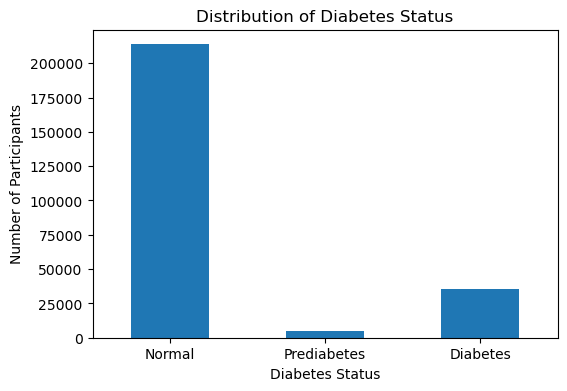

In [10]:
plt.figure(figsize=(6,4))

df["Diabetes_012"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xticks(
    [0,1,2],
    ["Normal","Prediabetes","Diabetes"],
    rotation=0
)

plt.xlabel("Diabetes Status")
plt.ylabel("Number of Participants")
plt.title("Distribution of Diabetes Status")

plt.show()

In [11]:
df.groupby("Diabetes_012")["BMI"].agg(["mean","median","std"])

,mean,median,std
Diabetes_012,,,
0.0,27.742521,27.0,6.260993
1.0,30.724466,30.0,6.964898
2.0,31.944011,31.0,7.363401


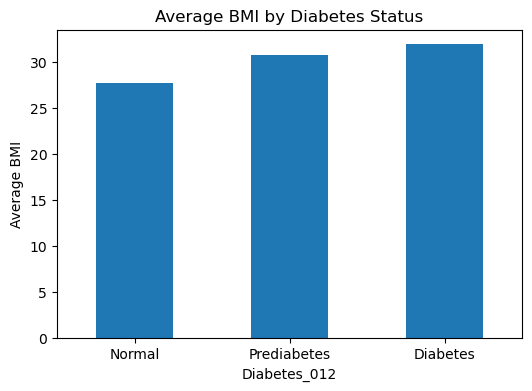

In [12]:
plt.figure(figsize=(6,4))

df.groupby("Diabetes_012")["BMI"].mean().plot(kind="bar")

plt.xticks(
    [0,1,2],
    ["Normal","Prediabetes","Diabetes"],
    rotation=0
)

plt.ylabel("Average BMI")
plt.title("Average BMI by Diabetes Status")

plt.show()

In [13]:
df.groupby("Diabetes_012")["HighBP"].mean()

Diabetes_012
0.0    0.371132
1.0    0.629022
2.0    0.752674
Name: HighBP, dtype: float64

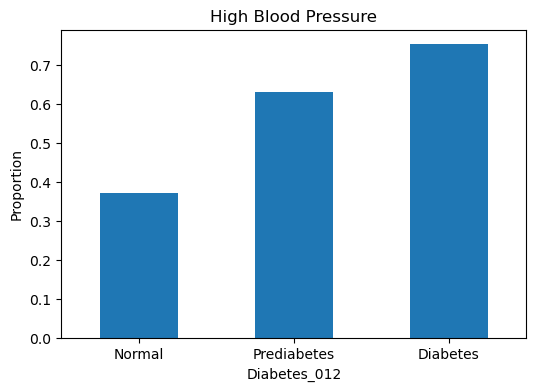

In [14]:
plt.figure(figsize=(6,4))

df.groupby("Diabetes_012")["HighBP"].mean().plot(kind="bar")

plt.xticks(
    [0,1,2],
    ["Normal","Prediabetes","Diabetes"],
    rotation=0
)

plt.ylabel("Proportion")
plt.title("High Blood Pressure")

plt.show()

In [15]:
df.groupby("Diabetes_012")["Age"].mean()

Diabetes_012
0.0    7.786559
1.0    9.083351
2.0    9.379053
Name: Age, dtype: float64

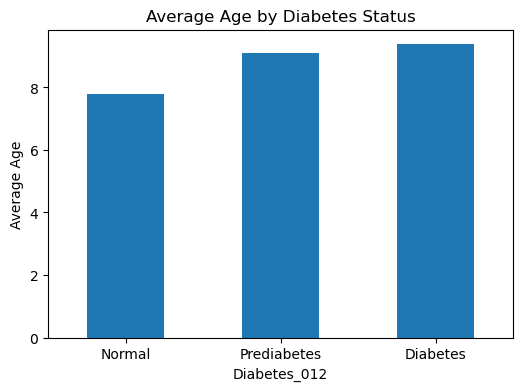

In [16]:
plt.figure(figsize=(6,4))

df.groupby("Diabetes_012")["Age"].mean().plot(kind="bar")

plt.xticks(
    [0,1,2],
    ["Normal","Prediabetes","Diabetes"],
    rotation=0
)

plt.ylabel("Average Age")
plt.title("Average Age by Diabetes Status")

plt.show()

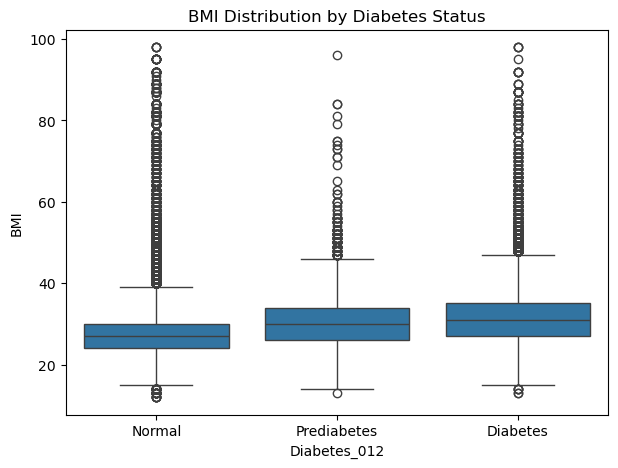

In [17]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Diabetes_012",
    y="BMI"
)

plt.xticks(
    [0,1,2],
    ["Normal","Prediabetes","Diabetes"]
)

plt.title("BMI Distribution by Diabetes Status")

plt.show()

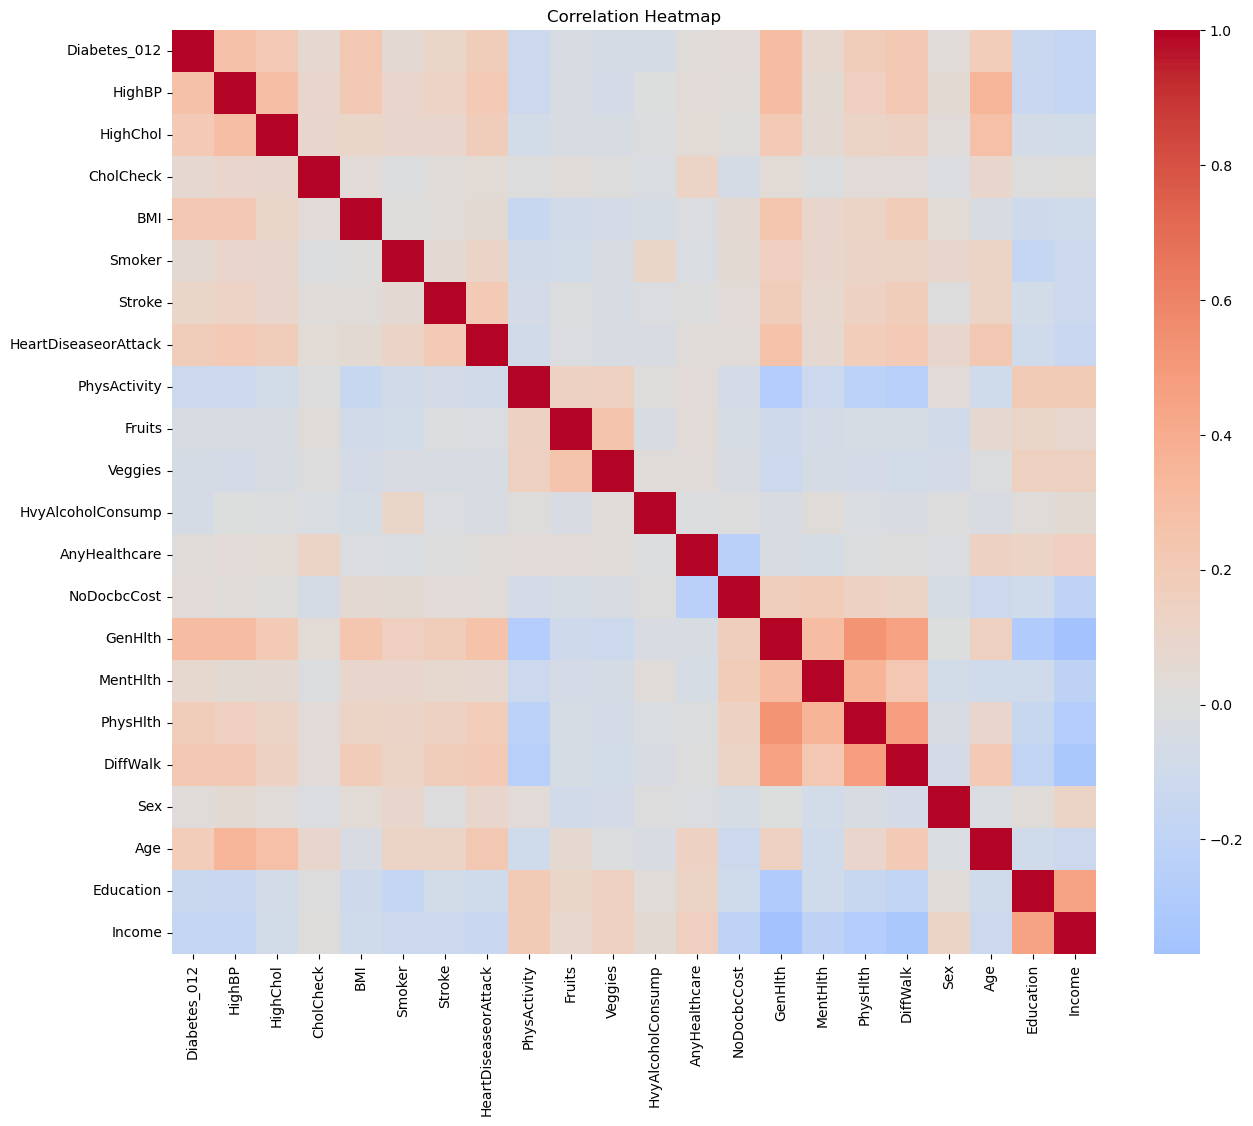

In [18]:
plt.figure(figsize=(15,12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
plt.figure(figsize=(8,8))

corr.drop("Diabetes_012").sort_values().plot(kind="barh")

plt.title("Correlation with Diabetes")

plt.show()

NameError: name 'corr' is not defined

<Figure size 800x800 with 0 Axes>

In [20]:
X = df.drop(columns=["Diabetes_012"])

y = df["Diabetes_012"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [23]:
# Features and Target
X = df.drop(columns=["Diabetes_012"])
y = df["Diabetes_012"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
print(X_train.shape)
print(X_test.shape)

(202944, 21)
(50736, 21)


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [27]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred = rf.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.8426


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.49      0.20      0.28      7069

    accuracy                           0.84     50736
   macro avg       0.45      0.39      0.40     50736
weighted avg       0.80      0.84      0.81     50736



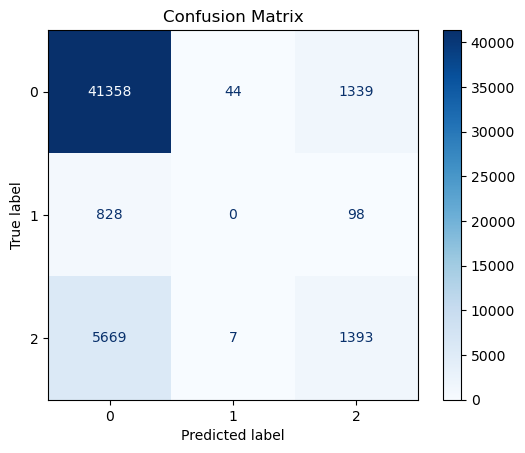

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,BMI,0.182486
18,Age,0.123139
20,Income,0.098170
15,PhysHlth,0.083555
19,Education,0.071265
13,GenHlth,0.070032
14,MentHlth,0.065171
0,HighBP,0.041773
4,Smoker,0.034209
8,Fruits,0.033710


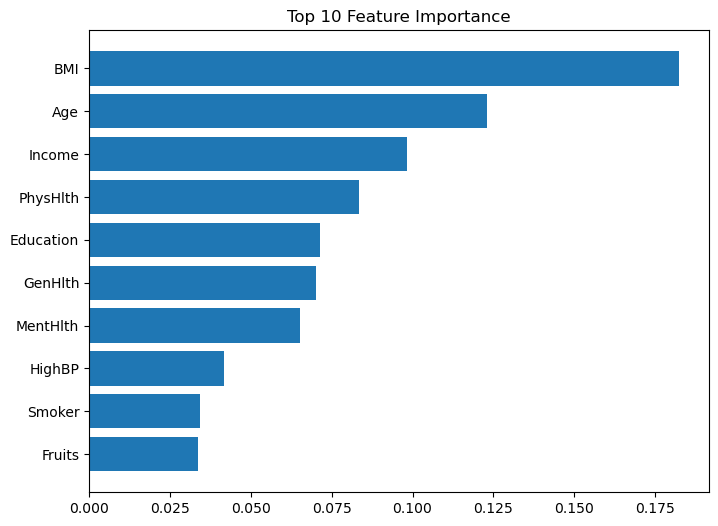

In [33]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance")

plt.show()

In [34]:
df_binary = df[df["Diabetes_012"] != 1].copy()

In [35]:
df_binary["Diabetes"] = df_binary["Diabetes_012"].replace({
    0: 0,
    2: 1
})

In [36]:
df_binary["Diabetes"].value_counts()

Diabetes
0.0    213703
1.0     35346
Name: count, dtype: int64

In [37]:
X = df_binary.drop(columns=["Diabetes_012", "Diabetes"])
y = df_binary["Diabetes"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

In [40]:
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     42741
         1.0       0.49      0.17      0.26      7069

    accuracy                           0.86     49810
   macro avg       0.68      0.57      0.59     49810
weighted avg       0.82      0.86      0.83     49810



In [42]:
print(y.value_counts())
print(y.value_counts(normalize=True))

Diabetes
0.0    213703
1.0     35346
Name: count, dtype: int64
Diabetes
0.0    0.858076
1.0    0.141924
Name: proportion, dtype: float64


In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[41449  1292]
 [ 5839  1230]]


In [44]:
y_prob = rf.predict_proba(X_test)[:,1]

print(y_prob.min())
print(y_prob.max())
print(y_prob.mean())

0.0
0.975
0.1434439854403229


In [45]:
import numpy as np

print(np.percentile(y_prob, [50, 75, 90, 95, 99]))

[0.075     0.225     0.4000831 0.505     0.675    ]


In [46]:
from sklearn.metrics import classification_report

for t in [0.5, 0.4, 0.3, 0.2]:
    y_pred = (y_prob >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred))


Threshold = 0.5
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     42741
         1.0       0.48      0.18      0.26      7069

    accuracy                           0.86     49810
   macro avg       0.68      0.57      0.59     49810
weighted avg       0.82      0.86      0.83     49810


Threshold = 0.4
              precision    recall  f1-score   support

         0.0       0.89      0.93      0.91     42741
         1.0       0.44      0.32      0.37      7069

    accuracy                           0.85     49810
   macro avg       0.67      0.63      0.64     49810
weighted avg       0.83      0.85      0.84     49810


Threshold = 0.3
              precision    recall  f1-score   support

         0.0       0.91      0.87      0.89     42741
         1.0       0.39      0.49      0.44      7069

    accuracy                           0.82     49810
   macro avg       0.65      0.68      0.67     49810
weighted avg       0.84

In [47]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [48]:
from xgboost import XGBClassifier

In [49]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

In [50]:
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [51]:
y_pred = xgb.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     42741
         1.0       0.59      0.19      0.28      7069

    accuracy                           0.87     49810
   macro avg       0.73      0.58      0.60     49810
weighted avg       0.84      0.87      0.83     49810



In [52]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.866111222646055


In [53]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                 Feature  Importance
0                 HighBP    0.571845
13               GenHlth    0.119129
1               HighChol    0.083257
10     HvyAlcoholConsump    0.032427
18                   Age    0.029734
3                    BMI    0.027813
2              CholCheck    0.025548
6   HeartDiseaseorAttack    0.024689
16              DiffWalk    0.021204
17                   Sex    0.013181
20                Income    0.009854
5                 Stroke    0.006472
19             Education    0.004481
7           PhysActivity    0.004383
15              PhysHlth    0.004028
9                Veggies    0.003881
4                 Smoker    0.003754
8                 Fruits    0.003721
14              MentHlth    0.003720
12           NoDocbcCost    0.003474
11         AnyHealthcare    0.003405


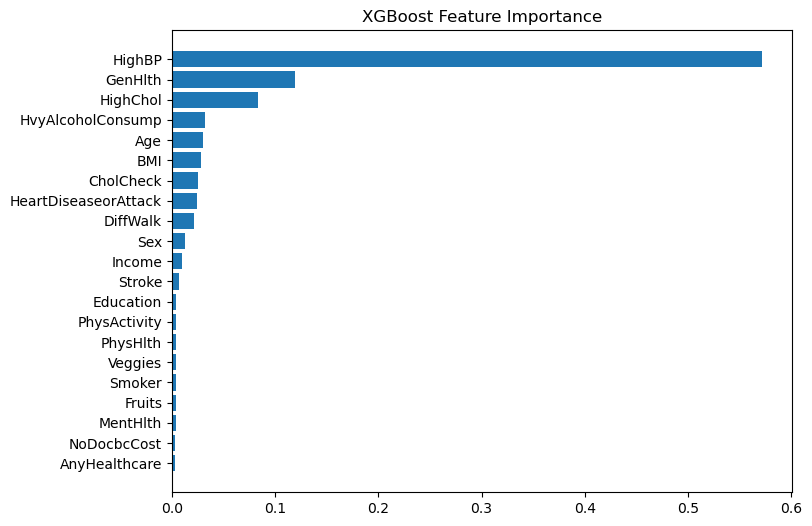

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")

plt.show()

In [55]:
y_prob = xgb.predict_proba(X_test)[:,1]

In [56]:
y_pred = (y_prob >= 0.3).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.89      0.90     42741
         1.0       0.44      0.51      0.47      7069

    accuracy                           0.84     49810
   macro avg       0.68      0.70      0.69     49810
weighted avg       0.85      0.84      0.84     49810



In [57]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("AUC :", auc)

AUC : 0.8371926450411364


In [58]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf_prob = rf.predict_proba(X_test)[:,1]
rf_pred = (rf_prob >= 0.3).astype(int)

rf_acc = accuracy_score(y_test, rf_pred)
rf_pre = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

In [60]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [61]:
print(xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


In [62]:
type(xgb)

xgboost.sklearn.XGBClassifier

In [63]:
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [64]:
print(hasattr(xgb, "_Booster"))

True


In [65]:
xgb.predict_proba(X_test[:5])

array([[0.9714647 , 0.02853532],
       [0.9451037 , 0.05489632],
       [0.9876439 , 0.01235611],
       [0.99331796, 0.00668203],
       [0.97831124, 0.02168876]], dtype=float32)

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# XGBoost 예측 확률
xgb_prob = xgb.predict_proba(X_test)[:,1]

# Threshold = 0.3
xgb_pred = (xgb_prob >= 0.3).astype(int)

# 성능 계산
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_pre = precision_score(y_test, xgb_pred)
xgb_rec = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("Accuracy :", xgb_acc)
print("Precision:", xgb_pre)
print("Recall   :", xgb_rec)
print("F1-score :", xgb_f1)
print("AUC      :", xgb_auc)

Accuracy : 0.8387873920899418
Precision: 0.44132372695078764
Recall   : 0.51124628660348
F1-score : 0.47371870494166995
AUC      : 0.8371926450411364


In [67]:
comparison = pd.DataFrame({
    "Model":["Random Forest","XGBoost"],
    "Accuracy":[rf_acc,xgb_acc],
    "Precision":[rf_pre,xgb_pre],
    "Recall":[rf_rec,xgb_rec],
    "F1-score":[rf_f1,xgb_f1],
    "ROC-AUC":[rf_auc,xgb_auc]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.820,0.394,0.493,0.438,0.805
1,XGBoost,0.839,0.441,0.511,0.474,0.837


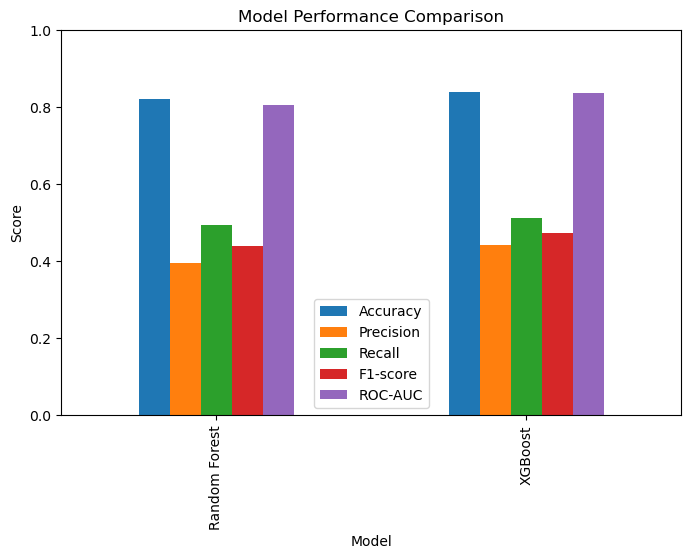

In [68]:
comparison.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.ylabel("Score")
plt.ylim(0,1)
plt.title("Model Performance Comparison")
plt.show()

In [69]:
import joblib

joblib.dump(xgb, "model.pkl")

['model.pkl']